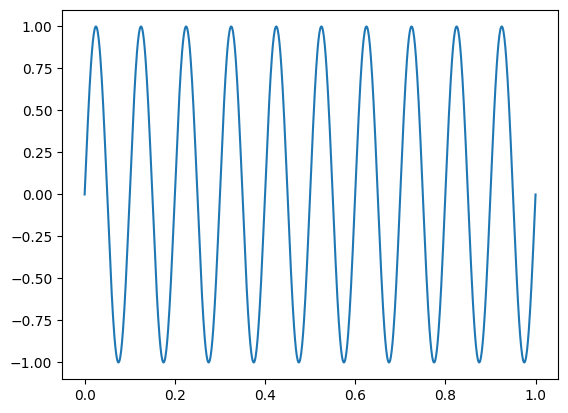

In [1]:
# waves with freqeuency 10... one with nyquist rate and the other with one which doesn't
import numpy as np
import matplotlib.pyplot as plt

fs = 10
t = np.linspace(0, 1, 1000)
x = np.sin(2 * np.pi * fs * t)

plt.plot(t, x)
plt.show()

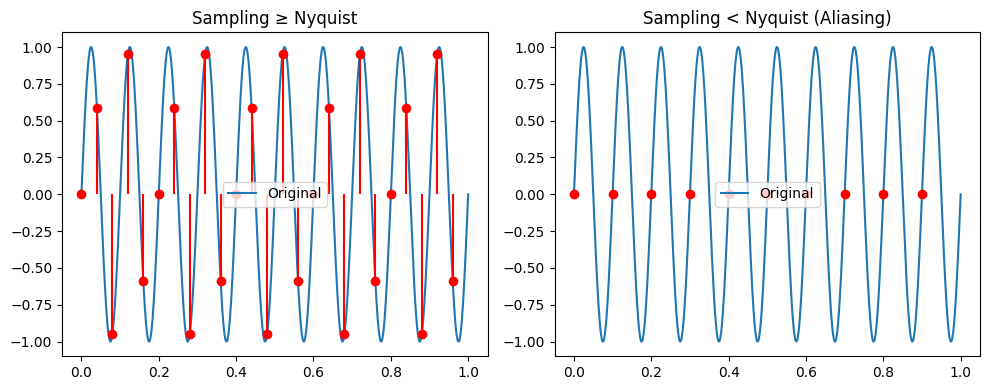

In [5]:
fs_nyquist = 25
fs_low = 10

t_nyq = np.arange(0, 1, 1/fs_nyquist)
x_nyq = np.sin(2*np.pi*fs*t_nyq)

t_low = np.arange(0, 1, 1/fs_low)
x_low = np.sin(2*np.pi*fs*t_low)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(t, x, label="Original")
plt.stem(t_nyq, x_nyq, linefmt='r-', markerfmt='ro', basefmt=" ")
plt.title("Sampling ≥ Nyquist")
plt.legend()

plt.subplot(1,2,2)
plt.plot(t, x, label="Original")
plt.stem(t_low, x_low, linefmt='r-', markerfmt='ro', basefmt=" ")
plt.title("Sampling < Nyquist (Aliasing)")
plt.legend()

plt.tight_layout()
plt.show()

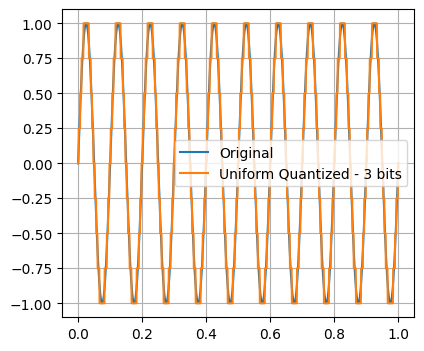

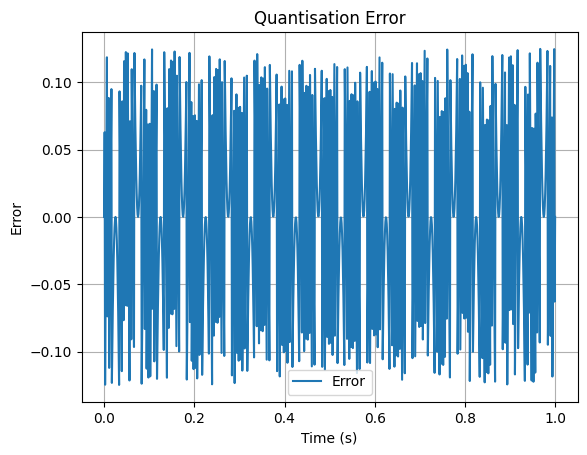

In [7]:
def uniform_quantize(signal, bits):
    levels = 2 ** bits
    min_val, max_val = -1, 1
    step = (max_val - min_val)/ levels
    quantized = np.round((signal - min_val)/step)*step + min_val
    return quantized

bits = 3
x_q = uniform_quantize(x, bits)

plt.figure(figsize = (10, 4))
plt.subplot(1, 2, 1)
plt.plot(t, x, label = "Original")
plt.plot(t, x_q, label = "Uniform Quantized - 3 bits")
plt.legend()
plt.grid(True)
plt.show()
error = x - x_q

plt.plot(t, error, label = "Error")
plt.title("Quantisation Error")
plt.xlabel("Time (s)")
plt.ylabel("Error")
plt.legend()
plt.grid(True)
plt.show()

Logarithmic expands low amplitudes, compresses high amplitudes

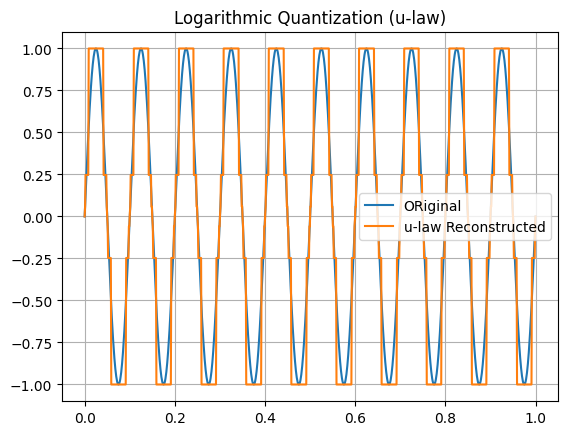

In [10]:
def mu_law_compress(signal, mu = 255):
    return np.sign(signal) * np.log1p(mu * np.abs(signal)) / np.log1p(mu)

def mu_law_expand(signal, mu = 255):
    return np.sign(signal) * (1/mu) * ((1 + mu)** np.abs(signal) - 1)

x_mu = mu_law_compress(x)

x_mu_q = uniform_quantize(x_mu, bits = 3)

x_reconstructed = mu_law_expand(x_mu_q)

plt.plot(t, x, label = "ORiginal")
plt.plot(t, x_reconstructed, label = "u-law Reconstructed")
plt.title("Logarithmic Quantization (u-law)")
plt.legend()
plt.grid(True)
plt.show()



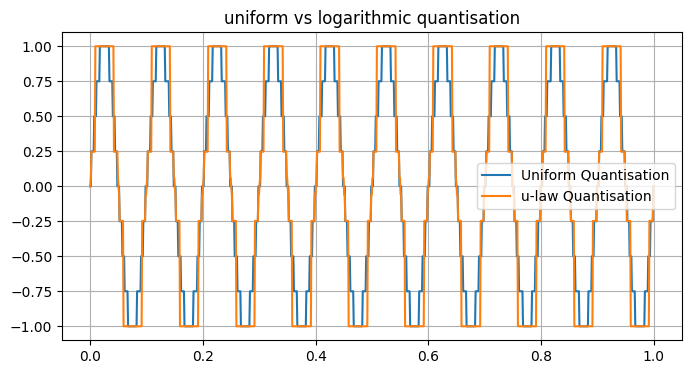

In [12]:
plt.figure(figsize=(8, 4))
plt.plot(t, x_q, label = "Uniform Quantisation")
plt.plot(t, x_reconstructed, label = "u-law Quantisation")
plt.title("uniform vs logarithmic quantisation")
plt.legend()
plt.grid(True)
plt.show()

In [14]:
f_signal = 50
f_max = f_signal
duration = 0.1

fs_cont = 100000
t_cont = np.linspace(0, duration, int(fs_cont * duration), endpoint = False)
x_cont = np.sin(2*np.pi*f_signal*t_cont)

fs_nyq = 3 * f_max
Ts = 1 / fs_nyq

t_samp = np.arange(0, duration, Ts)
x_samp = np.sin(2*np.pi*f_signal*t_samp)

def sinc_reconstruction(t, ts, xs, fs):
    x_rec = np.zeros_like(t)
    for n in range(len(ts)):
        x_rec += xs[n] * np.sinc(fs * (t - ts[n]))
    return x_rec

x_rec = sinc_reconstruction(t_cont, t_samp, x_samp, fs_nyq)


error = x_cont - x_rec
mse = np.mean(error**2)

print("Mean Squared Error (Nyquist sampling):", mse)




Mean Squared Error (Nyquist sampling): 0.0043678761309954555
